In [1]:
import matplotlib.pyplot as plt

In [2]:
import seaborn as sns

In [3]:
import numpy as np

In [4]:
import pandas as pd

In [5]:
import scanpy as sc

In [6]:
import scvi

/opt/conda/envs/autoimmune/lib/python3.9/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/opt/conda/envs/autoimmune/lib/python3.9/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
/opt/conda/envs/autoimmune/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
import gc

In [8]:
#pip install scikit-misc --force

In [9]:
print(scvi.__version__)

1.1.1


In [10]:
adata = sc.read_h5ad('Myeloid_B_T_From_Tissue_label_transfert_Subset_annotated_Milo_3K.h5ad')

In [11]:
adata.var.columns

Index(['mt-0', 'rb-0', 'n_cells_by_counts-0-0-0-0', 'mean_counts-0-0-0-0',
       'pct_dropout_by_counts-0-0-0-0', 'total_counts-0-0-0-0',
       'n_cells_by_counts-1-0-0-0', 'mean_counts-1-0-0-0',
       'pct_dropout_by_counts-1-0-0-0', 'total_counts-1-0-0-0',
       ...
       'total_counts-1-0-2', 'gene_symbol-1-0-0-0-0-0-0-1-1-2',
       'n_cells_by_counts-0-0-0-0-2', 'mean_counts-0-0-0-0-2',
       'pct_dropout_by_counts-0-0-0-0-2', 'total_counts-0-0-0-0-2',
       'n_cells_by_counts-1-0-0-0-2', 'mean_counts-1-0-0-0-2',
       'pct_dropout_by_counts-1-0-0-0-2', 'total_counts-1-0-0-0-2'],
      dtype='object', length=105)

In [12]:
adata.obs.columns

Index(['tissue', 'disease', 'donor_id', 'dataset_id', 'sex',
       'development_stage', 'batch', 'majority_voting', 'conf_score',
       '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes',
       'disease_status', 'age', 'developmental_stage', 'barcode', 'sample_id',
       'Site', 'Enrichment', 'Location', 'full_clustering',
       'log1p_total_counts', 'Cell_type_scANVI', 'disease_short',
       'nhood_kth_distance', 'tissue_harmo', 'disease_short_2', 'tissue_short',
       'disease_tissue', 'cell_type2', 'majority_voting_2', 'leiden_2',
       'leiden_3', 'relabeled_cells_2', 'relabeled_cells_3'],
      dtype='object')

In [13]:
adata.obs['batch'].value_counts()

2    209036
0     82334
1     73833
Name: batch, dtype: int64

In [14]:
sc.pp.highly_variable_genes(
    adata, 
    flavor="seurat_v3", 
    n_top_genes=2000, 
    layer="counts", 
    batch_key="dataset_id",
    subset=True
)

/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:64: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(


In [15]:
adata.obs[['dataset_id', 'tissue']].value_counts()

dataset_id                   tissue            
Kong_et_al_2023              ileum                 68479
GSE134809_Martin_et_al_2019  Ileum                 47390
E-MTAB-9492_Penkava_2020     Synovial fluid        38255
E-MTAB-8322_Stefeno_2020     synovial membrane     36031
GSE121380_Huang_2019         Colon                 36014
Qian_Yue_Zhang_2022          Thyroid               33413
Elmentaite_2020              Terminal ileum        33363
Kong_et_al_2023              colon                 32575
Martin_JIA_2019              Synovial fluid        18862
GSE163314_Lefferts_2021      Retrosigmoid Colon     9560
E-MTAB-8322_Stefeno_2020     Synovial membrane      5542
GSE161500_Abji_2020          Synovial fluid         2137
Elmentaite_2020              terminal ileum         1539
GSE121380_Huang_2019         colon                  1392
E-MTAB-9492_Penkava_2020     Synovial membrane       651
dtype: int64

In [16]:
scvi.model.SCVI.setup_anndata(adata, layer="counts", batch_key="donor_id")

/opt/conda/envs/autoimmune/lib/python3.9/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scvi/data/fields/_base_field.py:64: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


In [30]:
vae = scvi.model.SCVI(adata, n_layers=3, n_latent=30, gene_likelihood="nb")

In [31]:
max_epochs_scvi = np.min([round((20000 / adata.n_obs) * 400), 400])

In [32]:
max_epochs_scvi

22

In [33]:
vae.train()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 22/22: 100%|██████████| 22/22 [10:14<00:00, 28.03s/it, v_num=1, train_loss_step=686, train_loss_epoch=687]

`Trainer.fit` stopped: `max_epochs=22` reached.


Epoch 22/22: 100%|██████████| 22/22 [10:14<00:00, 27.94s/it, v_num=1, train_loss_step=686, train_loss_epoch=687]


In [34]:
vae.save("scVI_Model_Myeloid_B_T_From_Tissue", overwrite=True, save_anndata=True)

In [35]:
vae = scvi.model.SCVI.load("scVI_Model_Myeloid_B_T_From_Tissue")

INFO     File scVI_Model_Myeloid_B_T_From_Tissue/model.pt already downloaded                                       


/opt/conda/envs/autoimmune/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(
/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scvi/data/fields/_base_field.py:64: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


In [36]:
adata.obsm["X_scVI"] = vae.get_latent_representation()

In [37]:
sc.pp.neighbors(adata, use_rep="X_scVI")

In [38]:
adata

AnnData object with n_obs × n_vars = 365203 × 2000
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'sex', 'development_stage', 'batch', 'majority_voting', 'conf_score', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'disease_status', 'age', 'developmental_stage', 'barcode', 'sample_id', 'Site', 'Enrichment', 'Location', 'full_clustering', 'log1p_total_counts', 'Cell_type_scANVI', 'disease_short', 'nhood_kth_distance', 'tissue_harmo', 'disease_short_2', 'tissue_short', 'disease_tissue', 'cell_type2', 'majority_voting_2', 'leiden_2', 'leiden_3', 'relabeled_cells_2', 'relabeled_cells_3', 'leiden'
    var: 'mt-0', 'rb-0', 'n_cells_by_counts-0-0-0-0', 'mean_counts-0-0-0-0', 'pct_dropout_by_counts-0-0-0-0', 'total_counts-0-0-0-0', 'n_cells_by_counts-1-0-0-0', 'mean_counts-1-0-0-0', 'pct_dropout_by_counts-1-0-0-0', 'total_counts-1-0-0-0', 'n_cells_by_counts-1-0-0', 'mean_counts-1-0-0', 'pct_dropout_by_counts-1-0-0', 'total_counts-1-0-0', 'gene_symbol-1-0-0-0-0-0-0-1-1-0', 'n_

In [39]:
sc.tl.leiden(adata, resolution=0.6)

IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out


In [40]:
sc.tl.umap(adata, min_dist=0.5, neighbors_key="neighbors", spread =1)

/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' wil

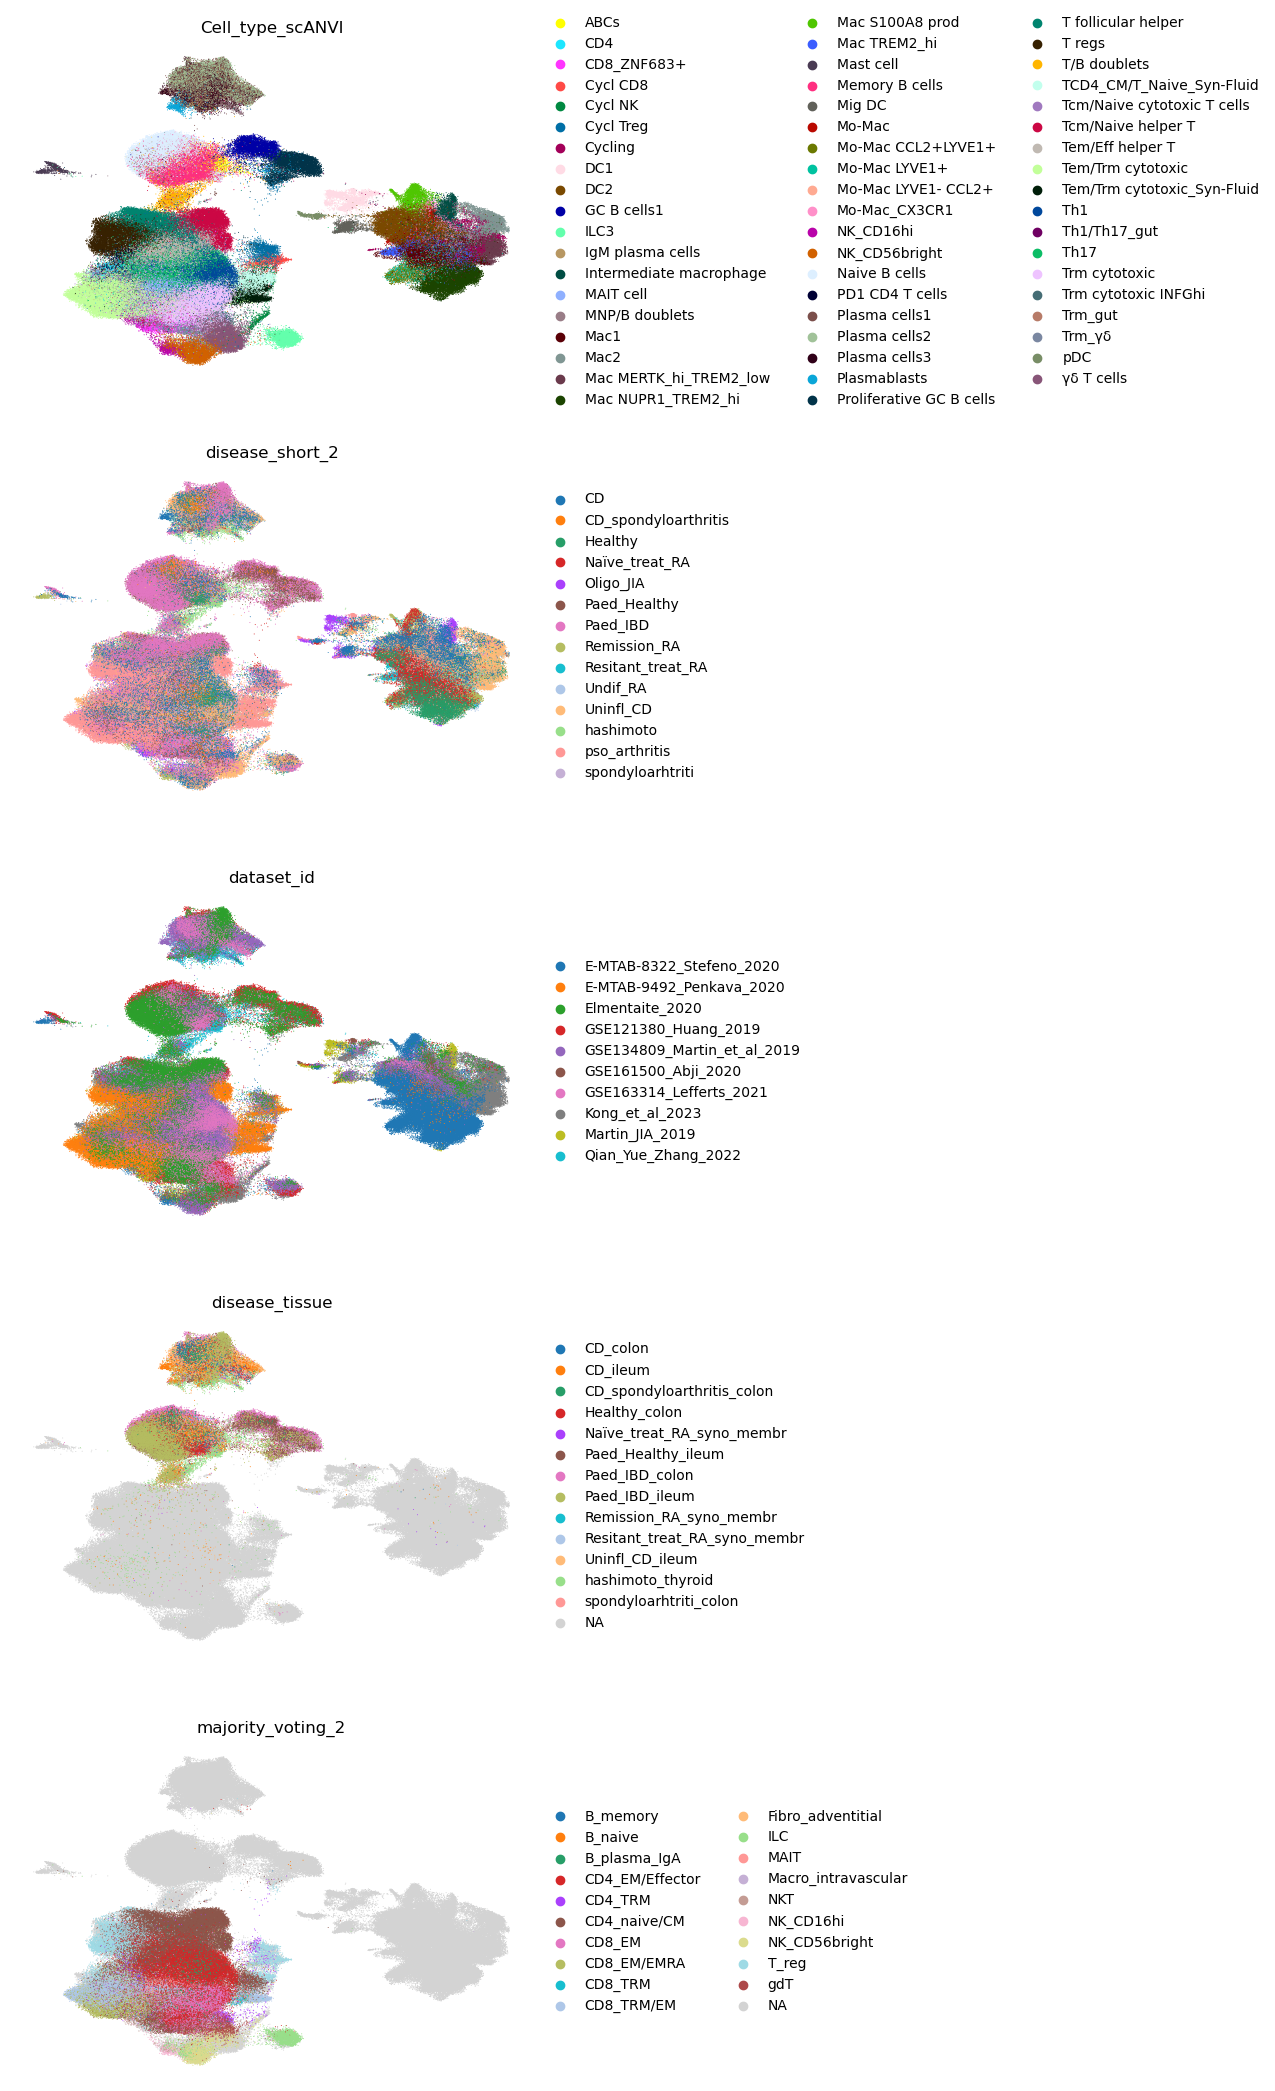

In [44]:
sc.pl.umap(
    adata,
    color=['Cell_type_scANVI', 'disease_short_2', 'dataset_id','disease_tissue', 'majority_voting_2'],
    frameon=False,
    size=2,
    ncols=1,
    use_raw=True,
    #legend_loc="on data"
)

In [45]:
def save_x_scvi(adata,data_dir, file_name, vae):
    """
    data_dir path to save scvi embedding
    file_name name for example Immune_compartment_PBMC
    """
   # x_scanvi = vae.get_latent_representation(adata)
    outname = "{fname}.scVI_out.npy".format(fname=file_name)
    modelname = "{fname}_scvi_model".format(fname=file_name)
    #np.save(data_dir + outname, x_scanvi)
    vae.save(data_dir + modelname, overwrite=True)
    pd.DataFrame(adata.obs).to_csv(data_dir+outname+".obs.csv")
    np.save(data_dir + file_name+".UMAP.npy", adata.obsm["X_umap"])

In [46]:
 save_x_scvi(adata=adata, data_dir="result_scvi/Myeloid_B_T_From_Tissue/", file_name="scVI_Myeloid_B_T_From_Tissue", vae=vae)

In [47]:
umap = adata.obsm["X_umap"]

In [48]:
umap = pd.DataFrame(umap, columns=["umap1", "umap2"])

In [49]:
umap

,umap1,umap2
0,0.122970,13.952169
1,0.282985,8.415564
2,-0.288593,8.597524
3,-0.630980,14.753313
4,1.085140,7.814439
...,...,...
365198,1.350270,-0.496049
365199,1.450526,-2.180768
365200,0.323231,0.026419
365201,0.572630,-0.601193


In [50]:
obs = adata.obs

In [51]:
umap.index = obs.index

In [52]:
obs["umap1"] = umap.umap1

obs["umap2"] = umap.umap2

In [53]:
obs.umap1

AAACCTGGTAGCACGA-1-1_0_0-0-0                  0.122970
AAACCTGGTCCGAGTC-1_0_0-0-0                    0.282985
AAACCTGTCAGTTAGC-1_0_0-0-0                   -0.288593
AAAGATGTCCTAAGTG-1-1_0_0-0-0                 -0.630980
AAAGCAATCTACGAGT-1_0_0-0-0                    1.085140
                                                ...   
TTTACTGTCATGGTCA-1-1-1-1-1-1-1_1_0_0-1-1-2    1.350270
TTTGCGCCATGCCCGA-1-1-1-1-1-1-1_1_0_0-1-1-2    1.450526
TTTGCGCGTAAACACA-1-1-1-1-1-1-1_1_0_0-1-1-2    0.323231
TTTGGTTCAATCCGAT-1-1-1-1-1-1-1_1_0_0-1-1-2    0.572630
TTTGTCAGTGATGCCC-1-1-1-1-1-1-1_1_0_0-1-1-2    0.803131
Name: umap1, Length: 365203, dtype: float32

In [54]:
obs.to_csv("Obs_Myeloid_B_T_From_PBMC_label_transfert_Subset_annotated_Milo_3K_with_UMAP_from_gpu.csv")

In [55]:
obs

,tissue,disease,donor_id,dataset_id,sex,development_stage,batch,majority_voting,conf_score,_scvi_batch,...,disease_tissue,cell_type2,majority_voting_2,leiden_2,leiden_3,relabeled_cells_2,relabeled_cells_3,leiden,umap1,umap2
AAACCTGGTAGCACGA-1-1_0_0-0-0,Thyroid,Hashimoto’s thyroiditis,HT12Thyroid,Qian_Yue_Zhang_2022,NaN,NaN,0,Plasma cells,0.947648,49,...,hashimoto_thyroid,NaN,NaN,NaN,NaN,NaN,NaN,6,0.122970,13.952169
AAACCTGGTCCGAGTC-1_0_0-0-0,Thyroid,Hashimoto’s thyroiditis,HT12Thyroid,Qian_Yue_Zhang_2022,NaN,NaN,0,Naive B cells,0.963530,49,...,hashimoto_thyroid,NaN,NaN,NaN,NaN,NaN,NaN,2,0.282985,8.415564
AAACCTGTCAGTTAGC-1_0_0-0-0,Thyroid,Hashimoto’s thyroiditis,HT12Thyroid,Qian_Yue_Zhang_2022,NaN,NaN,0,Naive B cells,0.912090,49,...,hashimoto_thyroid,NaN,NaN,NaN,NaN,NaN,NaN,2,-0.288593,8.597524
AAAGATGTCCTAAGTG-1-1_0_0-0-0,Thyroid,Hashimoto’s thyroiditis,HT12Thyroid,Qian_Yue_Zhang_2022,NaN,NaN,0,Plasma cells,0.989998,49,...,hashimoto_thyroid,NaN,NaN,NaN,NaN,NaN,NaN,6,-0.630980,14.753313
AAAGCAATCTACGAGT-1_0_0-0-0,Thyroid,Hashimoto’s thyroiditis,HT12Thyroid,Qian_Yue_Zhang_2022,NaN,NaN,0,Naive B cells,0.775685,49,...,hashimoto_thyroid,NaN,NaN,NaN,NaN,NaN,NaN,2,1.085140,7.814439
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTACTGTCATGGTCA-1-1-1-1-1-1-1_1_0_0-1-1-2,Retrosigmoid Colon,CD + Spondyloarthritis,Patient_2_Colon_GSM4976992,GSE163314_Lefferts_2021,NaN,NaN,2,Type 1 helper T cells,0.422139,169,...,NaN,7,B_plasma_IgA,5,5,Th1,Th1,0,1.350270,-0.496049
TTTGCGCCATGCCCGA-1-1-1-1-1-1-1_1_0_0-1-1-2,Retrosigmoid Colon,CD + Spondyloarthritis,Patient_2_Colon_GSM4976992,GSE163314_Lefferts_2021,NaN,NaN,2,Type 1 helper T cells,0.398410,169,...,NaN,7,B_plasma_IgA,5,5,Th1,Th1,0,1.450526,-2.180768
TTTGCGCGTAAACACA-1-1-1-1-1-1-1_1_0_0-1-1-2,Retrosigmoid Colon,CD + Spondyloarthritis,Patient_2_Colon_GSM4976992,GSE163314_Lefferts_2021,NaN,NaN,2,Type 1 helper T cells,0.421337,169,...,NaN,7,B_plasma_IgA,7,6,Th17,Th17,0,0.323231,0.026419
TTTGGTTCAATCCGAT-1-1-1-1-1-1-1_1_0_0-1-1-2,Retrosigmoid Colon,CD + Spondyloarthritis,Patient_2_Colon_GSM4976992,GSE163314_Lefferts_2021,NaN,NaN,2,Type 1 helper T cells,0.121884,169,...,NaN,"6,0",B_plasma_IgA,3,5,T follicular helper,T follicular helper,0,0.572630,-0.601193


In [56]:
!rclone copy Obs_Myeloid_B_T_From_PBMC_label_transfert_Subset_annotated_Milo_3K_with_UMAP_from_gpu.csv\
'gdrive:Projects/SCVI_Results/Milo_combine/'